In [9]:
%load_ext autoreload
%autoreload 2
%reset -f

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Imports

In [10]:
from locallib.picarrodb import *
from locallib.query import *
from locallib.box import *
from locallib.query import *

import pandas as pd
import geopandas as gpd
import contextily as ctx
import pandas as pd
import os

import sys
import os

%matplotlib widget
import matplotlib.pyplot as plt
from shapely import wkt
from shapely.ops import unary_union
import matplotlib.pyplot as plt
from h3 import *
from shapely.geometry import Point


os.chdir('/home/sandbox/personal-repos/DA-3507/dump')
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../lib')))
from custom_pandas import *

## Get the surveys

In [11]:
a = get_reports('Cadent',years = [2026]).execute([EU2_Conn])

In [12]:
report_bc = a.iloc[[-1]].copy()

In [13]:
report_bc.db.set_query(query_SurveyH3Aggregation_byReport(report_table = '#TempReport'))
agg_segments =report_bc.db.execute([EU2_Conn], source_col = 'ReportId', temp_table_name = '#TempReport')
report_bc.db.set_query(query_Segments_byReport(report_table = '#TempReport'))
segments = report_bc.db.execute([EU2_Conn], source_col = 'ReportId', temp_table_name = '#TempReport')

In [14]:
agg_segments['Breadcrumb_wkt'] = agg_segments['Breadcrumb'].apply(wkt.loads)
agg_segments_gdf = gpd.GeoDataFrame(agg_segments, geometry = 'Breadcrumb_wkt', crs = 'EPSG:4326')
utm_crs = agg_segments_gdf.estimate_utm_crs()
agg_segments_gdf = agg_segments_gdf.to_crs(utm_crs)
agg_segments_gdf['offset'] = agg_segments_gdf['Breadcrumb_wkt'].apply(lambda x: x.buffer(5))

In [15]:
segments_survey = segments
segments_survey['Breadcrumb_wkt'] = segments_survey['Breadcrumb'].apply(wkt.loads)
segments_survey_gdf = gpd.GeoDataFrame(segments_survey, geometry = segments_survey['Breadcrumb_wkt'], crs = 'EPSG:4326')
segments_survey_gdf = segments_survey_gdf.to_crs(utm_crs)
# cap_style options:
#   1 or 'round'  - round cap (default)
#   2 or 'flat'   - flat (butt) cap
#   3 or 'square' - square cap
agg_segments_gdf['offset'] = agg_segments_gdf['Breadcrumb_wkt'].apply(lambda x: x.buffer(5, cap_style=2))
from shapely.geometry import LineString, Point
import numpy as np

def sample_linearly(line, distance):
    if not isinstance(line, LineString):
        return []
    length = line.length
    # Compute evenly spaced distances along the line, always include endpoints
    num_points = int(np.floor(length / distance)) + 1
    if np.isclose(num_points * distance, length):
        distances = np.linspace(0, length, num=num_points + 1)
    else:
        distances = np.arange(0, length, distance)
        if length not in distances:
            distances = np.append(distances, length)
    return [line.interpolate(d) for d in distances]

def expected_num_points(line, samples):
    geom_length = line.length
    expected = int(np.floor(geom_length / samples)) + 1
    if not np.isclose(expected * samples, geom_length):
        expected += 1  # include last endpoint if not exactly at interval
    return expected

samples = 10
segments_survey_gdf['EvenlySpaced'] = segments_survey_gdf.geometry.apply(lambda line: sample_linearly(line, samples))
segments_survey_gdf['offset'] = segments_survey_gdf.geometry.buffer(5, cap_style=2)
segments_survey_gdf['NumPoints'] = segments_survey_gdf['EvenlySpaced'].apply(len)
segments_survey_gdf['ExpectedNumPoints'] = segments_survey_gdf['geometry'].apply(lambda line: expected_num_points(line, samples))
segments_survey_gdf['Length'] = segments_survey_gdf['geometry'].apply(lambda line: line.length)
segments_survey_gdf['Area'] = segments_survey_gdf['offset'].apply(lambda line: line.area)
segments_survey_gdf['LinearDensity'] = segments_survey_gdf['ExpectedNumPoints']/segments_survey_gdf['Length']
segments_survey_gdf['AreaDensity'] = segments_survey_gdf['ExpectedNumPoints']/segments_survey_gdf['Area']

In [16]:
surveys = segments_survey_gdf['SurveyId'].unique()
single_survey = segments_survey_gdf
points = single_survey.explode('EvenlySpaced', ignore_index=True)['EvenlySpaced']
single_survey_gdf = gpd.GeoDataFrame(single_survey, geometry=single_survey.offset, crs=single_survey.crs)
points_gdf = gpd.GeoDataFrame({'geometry': points})
points_gdf['index'] = points_gdf.index
points_gdf.set_index('index', inplace=True)
points_gdf.crs = single_survey.crs

In [17]:
joined = gpd.sjoin(points_gdf, single_survey_gdf, how="left", predicate="intersects")

In [18]:
summarised = joined.groupby('offset').agg({'index_right': 'count', 'LinearDensity': 'first', 'AreaDensity': 'first','offset': 'first','Length': 'first','Area': 'first','ExpectedNumPoints': 'first'}).rename(columns={'index_right': 'points'})
summarised['LinearDensityC'] = summarised['points']/summarised['Length']
summarised['AreaDensityC'] = summarised['points']/summarised['Area']
summarised['Passes'] = summarised['LinearDensityC']/summarised['LinearDensity']
summarised.sort_values(by = 'Passes', inplace = True)
summarised.head(20)

,points,LinearDensity,AreaDensity,offset,Length,Area,ExpectedNumPoints,LinearDensityC,AreaDensityC,Passes
offset,,,,,,,,,,
"POLYGON ((703178.373 5715657.537, 703177.812 5...",2,13.287046,1.328705,"POLYGON ((703178.373 5715657.537, 703177.812 5...",0.150523,1.505225,2,13.287046,1.328705,1.000000
"POLYGON ((703257.256 5715679.790, 703257.466 5...",2,0.412732,0.041273,"POLYGON ((703257.256 5715679.790, 703257.466 5...",4.845762,48.457624,2,0.412732,0.041273,1.000000
"POLYGON ((702666.190 5715023.762, 702659.059 5...",4,0.429891,0.042989,"POLYGON ((702666.190 5715023.762, 702659.059 5...",4.652344,46.523445,2,0.859782,0.085978,2.000000
"POLYGON ((702875.598 5715356.236, 702875.683 5...",48,0.105491,0.017510,"POLYGON ((702875.598 5715356.236, 702875.683 5...",199.069304,1199.324009,21,0.241122,0.040023,2.285714
"POLYGON ((703034.118 5715148.344, 703034.525 5...",15,0.149937,0.015004,"POLYGON ((703034.118 5715148.344, 703034.525 5...",40.016784,399.888745,6,0.374843,0.037510,2.500000
"POLYGON ((702660.380 5715233.488, 702660.355 5...",56,0.109530,0.020293,"POLYGON ((702660.380 5715233.488, 702660.355 5...",200.857446,1084.098465,22,0.278805,0.051656,2.545455
"POLYGON ((702662.569 5715229.548, 702659.947 5...",56,0.105202,0.019305,"POLYGON ((702662.569 5715229.548, 702659.947 5...",199.616780,1087.820019,21,0.280538,0.051479,2.666667
"POLYGON ((703066.916 5715152.851, 703068.137 5...",16,0.139523,0.013952,"POLYGON ((703066.916 5715152.851, 703068.137 5...",43.003516,430.035159,6,0.372063,0.037206,2.666667
"POLYGON ((703010.344 5715140.863, 703015.539 5...",9,0.197889,0.019789,"POLYGON ((703010.344 5715140.863, 703015.539 5...",15.159981,151.599807,3,0.593668,0.059367,3.000000


<Axes: >

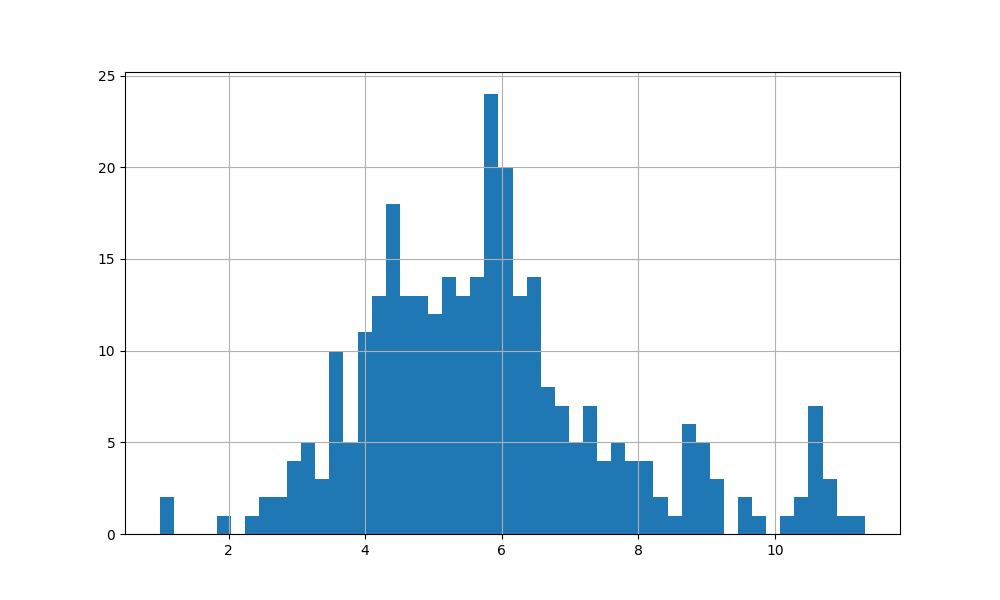

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
passes = summarised['Passes']
passes.hist(bins=50, ax=ax)

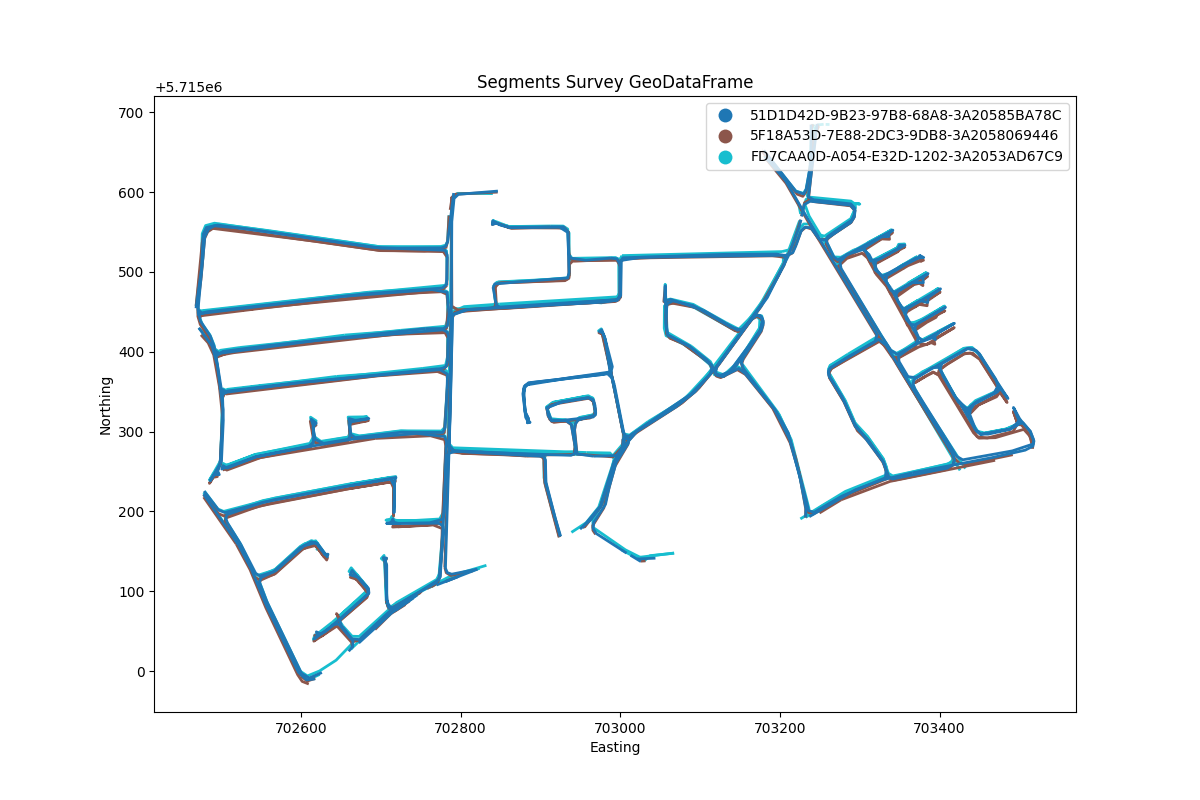

In [20]:
fig, ax = plt.subplots(figsize=(12, 8))
segments_survey_gdf.plot(ax=ax, column='SurveyId', legend=True, linewidth=2)
ax.set_title("Segments Survey GeoDataFrame")
ax.set_xlabel("Easting")
ax.set_ylabel("Northing")
plt.show()